# A simple example using HESS-I

In [1]:
import astropy.units as u
import jax
import jax.numpy as jnp
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

from nyx.atmosphere import single_scattering
from nyx.core import Scene
from nyx.core.geometry import Geometry
from nyx.core.observation import Observation
from nyx.emitter import Airglow, Moon, Stars, ZodiacalLight
from nyx.instrument import EffectiveApertureInstrument

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Building the model:

We first need to determine the render geometry:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 50) * u.nm,  # wavelength grid
    nside=16,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

E0827 19:18:09.988787  728083 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


We build out telescope using iactrace:

In [3]:
from iactrace import Camera, Telescope

In [4]:
telescope = Telescope.from_yaml("../../../iactrace/configs/HESS/CT3.yaml", n_samples=128, key=jax.random.key(0))
camera = Camera.from_yaml("../../../iactrace/configs/HESS/HESS1U.yaml")

In [5]:
%%time
half_angle = jnp.deg2rad(3.0)
instrument = EffectiveApertureInstrument.from_iactrace(geo, telescope, camera, half_angle=half_angle, step = half_angle/256, wavelengths=jnp.linspace(200,700), progress=True)

CPU times: user 1min 10s, sys: 1min 39s, total: 2min 49s
Wall time: 3min 16s


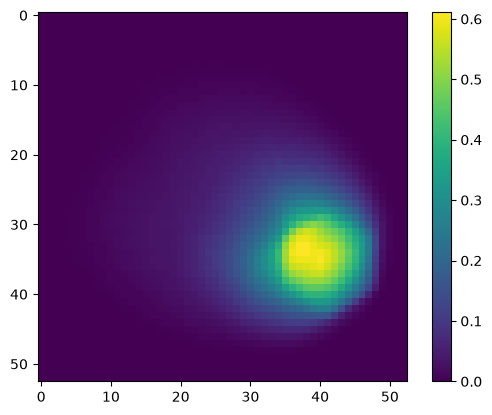

In [6]:
import matplotlib.pyplot as plt
plt.imshow(instrument._pixel_values[0])
plt.colorbar()

In [10]:
hess_ct1 = EffectiveApertureInstrument.load("../../nyx/data/HESS_CT1.h5", geo)

We then load instrument, atmospheric model and source models:

In [3]:
hess_ct1 = EffectiveApertureInstrument.load("../../nyx/data/HESS_CT1.h5", geo)
hess_stereo = {"CT1": hess_ct1, "CT2": hess_ct1, "CT3": hess_ct1, "CT4": hess_ct1}

atmosphere = single_scattering.HGOzoneAbsorption(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

## Creating an example observation:
An observations consists out of a single target, an array of observations times and locations:

In [4]:
location_ct1 = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
location_ct2 = EarthLocation.from_geodetic(
    lon=16.50010 * u.deg,
    lat=-23.27075 * u.deg,
    height=1.835 * u.km,
)
location_ct3 = EarthLocation.from_geodetic(
    lon=16.49925 * u.deg,
    lat=-23.27151 * u.deg,
    height=1.835 * u.km,
)
location_ct4 = EarthLocation.from_geodetic(
    lon=16.50012 * u.deg,
    lat=-23.27232 * u.deg,
    height=1.835 * u.km,
)

times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 30, 12) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs_ct1 = Observation(location_ct1, times, target, geo)
obs_ct2 = Observation(location_ct2, times, target, geo)
obs_ct3 = Observation(location_ct3, times, target, geo)
obs_ct4 = Observation(location_ct4, times, target, geo)

observations = {"CT1": obs_ct1, "CT2": obs_ct2, "CT3": obs_ct3, "CT4": obs_ct4}

## Querying model for scene
We then build our scene from the models an observations:

In [5]:
scene = Scene.build(hess_stereo, atmosphere, sources, observations)

You can look at a hemispherical model of the scene calculated over the healpix map:

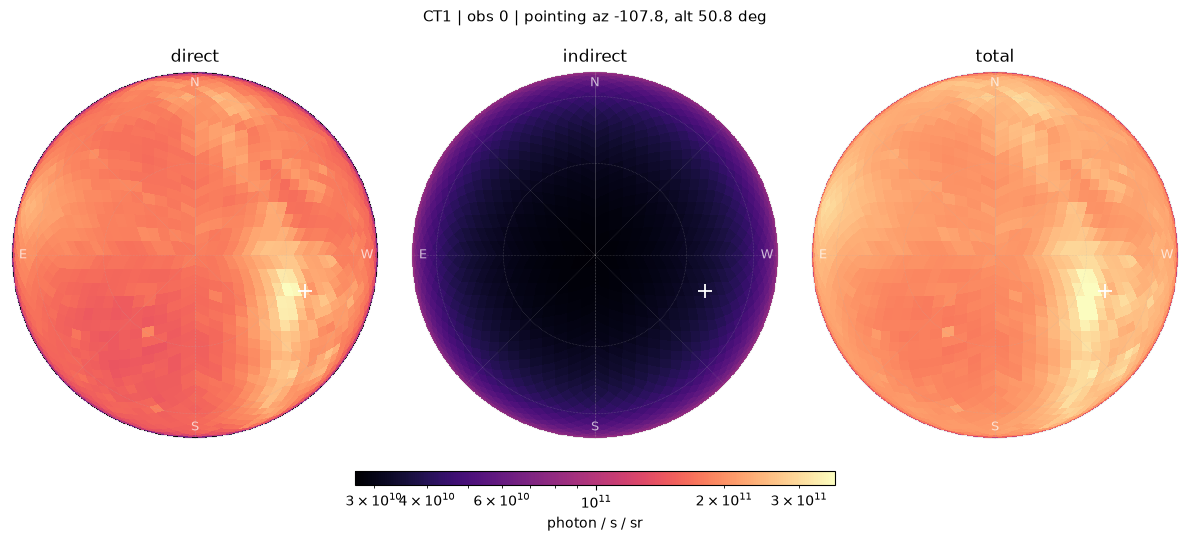

In [13]:
view = scene.sky_view(instrument='CT1')
fview = view.plot()

You can profile the scene before rendering:

In [7]:
from nyx.utils.profiler import profile_render

profile_render(scene)


  Render memory profile (backend=gpu, device=cuda:0)
  Memory before render: 41.8 MB
  Memory after render:  42.0 MB
  Peak memory:          504.9 MB
  Render overhead:      0.2 MB
  Result shape:         (12, 960)
  Output[CT1]:            (12, 960)  float32  0.04 MB
  Output[CT2]:            (12, 960)  float32  0.04 MB
  Output[CT3]:            (12, 960)  float32  0.04 MB
  Output[CT4]:            (12, 960)  float32  0.04 MB

  Device memory (cuda:0):
    In use:      42.0 MB
    Peak:       504.9 MB
    Limit:    36406.0 MB
    Free:     36364.0 MB



{'before_mb': 41.75341796875,
 'after_mb': 41.980712890625,
 'peak_mb': 504.882080078125,
 'render_mb': 0.227294921875,
 'result_shape': (12, 960)}

We can then render the whole scene with one call:

In [8]:
%%time
rates = scene.render()

CPU times: user 1.25 s, sys: 180 ms, total: 1.43 s
Wall time: 1.15 s


By default, this is not jitted. To increase call speed after the first call, you can use jax.jit:

In [9]:
@jax.jit
def f_render():
    return scene.render()

This incurs a higher upfront cost, but future calls are accelerated via jitting:

In [10]:
%%time
rates = jax.block_until_ready(f_render())

CPU times: user 12.7 s, sys: 457 ms, total: 13.1 s
Wall time: 7.69 s


In [11]:
%%time
rates = jax.block_until_ready(f_render())

CPU times: user 601 μs, sys: 964 μs, total: 1.57 ms
Wall time: 2.51 ms


## Plotting the result:
We can plot the generated plot for all four of our telescopes using iactrace:

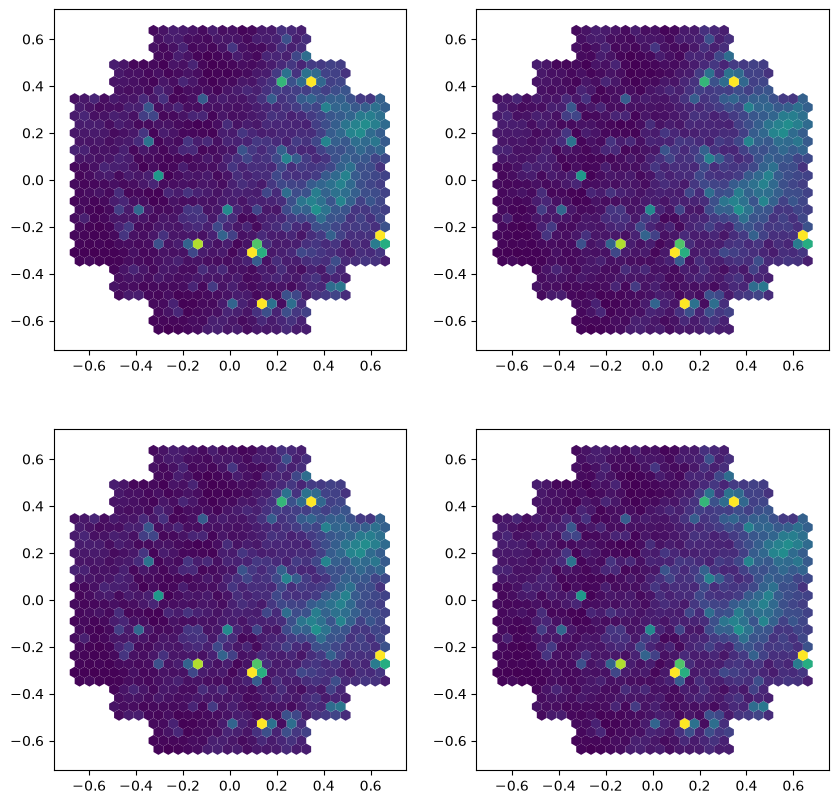

In [12]:
import matplotlib.pyplot as plt
from iactrace import Camera, show_image

camera = Camera.from_yaml("../../../iactrace/configs/HESS/HESS1U.yaml")

id = 0
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
ax1 = show_image(rates["CT1"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[0, 0], vmax=500)
ax1 = show_image(rates["CT2"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[0, 1], vmax=500)
ax1 = show_image(rates["CT3"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[1, 0], vmax=500)
ax1 = show_image(rates["CT4"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[1, 1], vmax=500)